In [1]:
# ============================================
# 1. Imports and reproducibility
# ============================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [2]:
# ============================================
# 2. Config
# ============================================
@dataclass
class Config:
    batch_size: int = 256
    epochs: int = 10
    learning_rate: float = 1e-3
    temperature: float = 0.5
    embedding_dim: int = 128
    num_workers: int = 2
    data_dir: str = "./data"
    num_classes: int = 10
    image_size: int = 32
    subset_for_visuals: int = 2000  # keep plots manageable

cfg = Config()
print(cfg)

Config(batch_size=256, epochs=10, learning_rate=0.001, temperature=0.5, embedding_dim=128, num_workers=2, data_dir='./data', num_classes=10, image_size=32, subset_for_visuals=2000)


In [3]:
# ============================================
# 3. Data augmentation for contrastive learning
# ============================================
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [4]:
# ============================================
# 4. Dataset for positive pairs
# ============================================
class ContrastiveCIFAR10(Dataset):
    def __init__(self, root, train=True, download=True, transform=None):
        self.dataset = datasets.CIFAR10(root=root, train=train, download=download)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        x1 = self.transform(image)
        x2 = self.transform(image)
        return x1, x2, label

train_contrastive_dataset = ContrastiveCIFAR10(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=contrastive_transform
)

train_eval_dataset = datasets.CIFAR10(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=eval_transform
)

test_eval_dataset = datasets.CIFAR10(
    root=cfg.data_dir,
    train=False,
    download=True,
    transform=eval_transform
)

train_contrastive_loader = DataLoader(
    train_contrastive_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    drop_last=True
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers
)

class_names = train_eval_dataset.classes
print(class_names)

100%|██████████| 170M/170M [00:02<00:00, 72.1MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


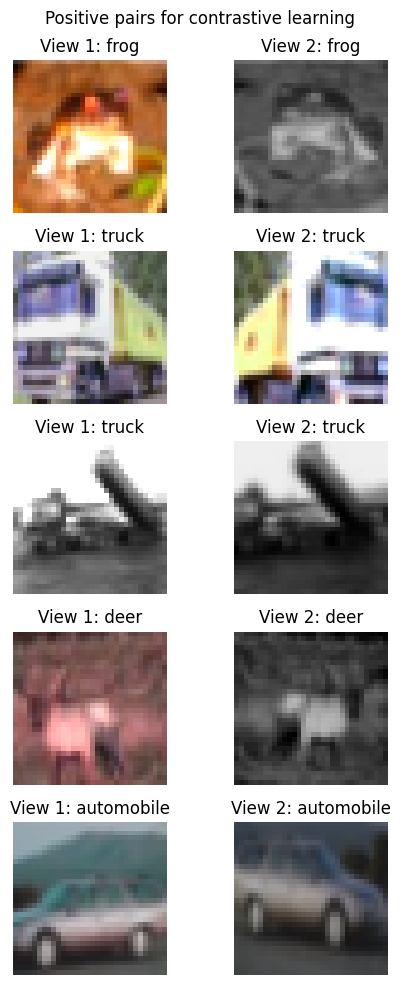

In [5]:
# ============================================
# 5. Visualize positive pairs
# ============================================
def unnormalize(img):
    img = img.clone().cpu()
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

def show_positive_pairs(dataset, n=5):
    fig, axes = plt.subplots(n, 2, figsize=(5, 2*n))
    for i in range(n):
        x1, x2, label = dataset[i]
        axes[i, 0].imshow(np.transpose(unnormalize(x1).numpy(), (1, 2, 0)))
        axes[i, 0].set_title(f"View 1: {class_names[label]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(np.transpose(unnormalize(x2).numpy(), (1, 2, 0)))
        axes[i, 1].set_title(f"View 2: {class_names[label]}")
        axes[i, 1].axis("off")

    plt.suptitle("Positive pairs for contrastive learning")
    plt.tight_layout()
    plt.show()

show_positive_pairs(train_contrastive_dataset, n=5)

In [6]:
# ============================================
# 6. Encoder + projection head
# ============================================
class SimCLRModel(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=None)

        # CIFAR-friendly stem
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.encoder = backbone
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        projections = F.normalize(projections, dim=1)
        return features, projections

model = SimCLRModel(embedding_dim=cfg.embedding_dim).to(DEVICE)
print(model.__class__.__name__)

SimCLRModel


In [7]:
# ============================================
# 7. NT-Xent / InfoNCE-style contrastive loss
# ============================================
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # [2B, D]

    similarity = torch.matmul(z, z.T) / temperature  # cosine because z normalized

    # mask self-similarity
    mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
    similarity = similarity.masked_fill(mask, -1e9)

    # positive indices
    positives = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=z.device),
        torch.arange(0, batch_size, device=z.device)
    ], dim=0)

    loss = F.cross_entropy(similarity, positives)
    return loss

In [8]:
# ============================================
# 8. Training loop
# ============================================
def train_contrastive(model, loader, epochs, lr, temperature):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": []}

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        total = 0

        for x1, x2, _ in loader:
            x1 = x1.to(DEVICE)
            x2 = x2.to(DEVICE)

            _, z1 = model(x1)
            _, z2 = model(x2)

            loss = nt_xent_loss(z1, z2, temperature=temperature)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x1.size(0)
            total += x1.size(0)

        epoch_loss = running_loss / total
        history["loss"].append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | Contrastive Loss: {epoch_loss:.4f}")

    return history

history = train_contrastive(
    model,
    train_contrastive_loader,
    epochs=cfg.epochs,
    lr=cfg.learning_rate,
    temperature=cfg.temperature
)

Epoch 01/10 | Contrastive Loss: 4.8965
Epoch 02/10 | Contrastive Loss: 4.6004
Epoch 03/10 | Contrastive Loss: 4.5352
Epoch 04/10 | Contrastive Loss: 4.5025
Epoch 05/10 | Contrastive Loss: 4.4836
Epoch 06/10 | Contrastive Loss: 4.4689
Epoch 07/10 | Contrastive Loss: 4.4564
Epoch 08/10 | Contrastive Loss: 4.4461
Epoch 09/10 | Contrastive Loss: 4.4373
Epoch 10/10 | Contrastive Loss: 4.4304


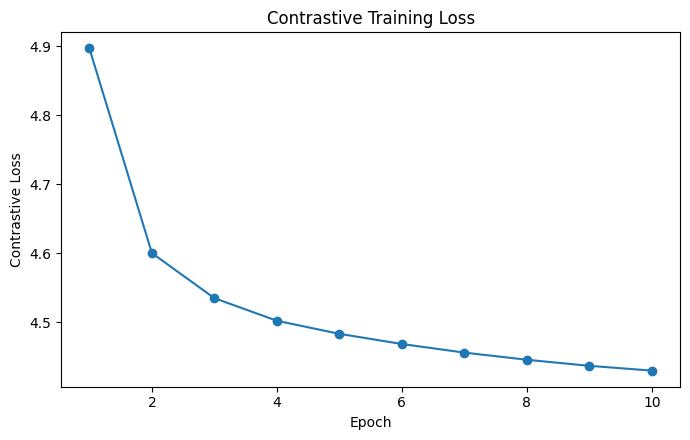

In [9]:
# ============================================
# 9. Plot contrastive training loss
# ============================================
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(history["loss"]) + 1), history["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Contrastive Training Loss")
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# 10. Feature extraction for visuals and evaluation
# ============================================
@torch.no_grad()
def extract_features(model, loader, max_samples=None):
    model.eval()
    all_features = []
    all_labels = []
    count = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        features, _ = model(images)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

        count += images.size(0)
        if max_samples is not None and count >= max_samples:
            break

    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    if max_samples is not None:
        features = features[:max_samples]
        labels = labels[:max_samples]

    return features, labels

train_features, train_labels = extract_features(
    model, train_eval_loader, max_samples=cfg.subset_for_visuals
)
test_features, test_labels = extract_features(
    model, test_eval_loader, max_samples=cfg.subset_for_visuals
)

print(train_features.shape, test_features.shape)

(2000, 512) (2000, 512)


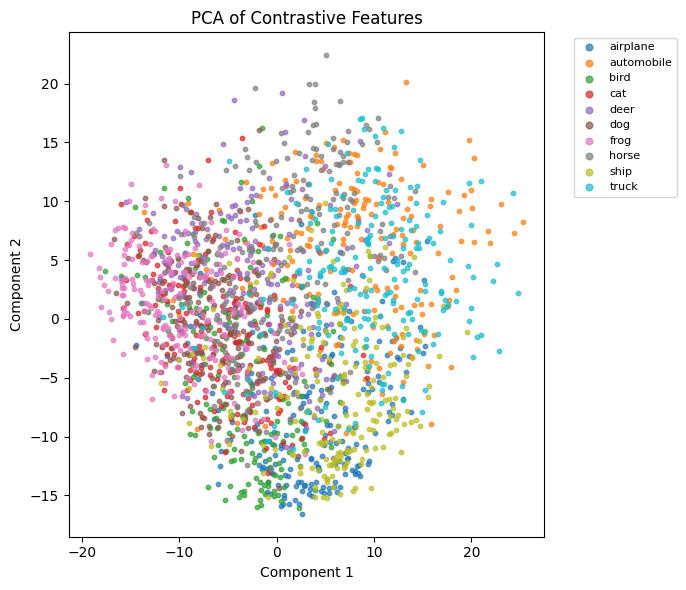

In [11]:
# ============================================
# 11. Embedding visualization with PCA / t-SNE
# ============================================
def plot_embeddings(features, labels, class_names, method="pca", title="Embedding Space"):
    if method.lower() == "pca":
        reducer = PCA(n_components=2, random_state=SEED)
    else:
        reducer = TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto")

    reduced = reducer.fit_transform(features)

    plt.figure(figsize=(7, 6))
    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_idx
        plt.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            s=10,
            alpha=0.7,
            label=class_name
        )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(fontsize=8, markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_embeddings(
    train_features,
    train_labels,
    class_names,
    method="pca",
    title="PCA of Contrastive Features"
)

In [12]:
# ============================================
# 12. Linear evaluation: train a classifier on learned features
# ============================================
# For a stronger report, compare this with a random/untrained encoder later.
clf = LogisticRegression(max_iter=1000, multi_class="auto")
clf.fit(train_features, train_labels)

preds = clf.predict(test_features)
acc = accuracy_score(test_labels, preds)
print(f"Linear evaluation accuracy on learned features: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear evaluation accuracy on learned features: 0.5890
